In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1 - Import Libraries

In [4]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

### 2 - Load ALL monthly CSV files
 (A minimum of 6 months of dataset)





In [5]:
DATA_PATH = "/content/drive/MyDrive/IDX_Exchange_Su26/data/california/"

files = glob.glob(DATA_PATH + "CRMLSSold*.csv")

print("num files:", len(files))
files[:5]

num files: 30


['/content/drive/MyDrive/IDX_Exchange_Su26/data/california/CRMLSSold202408.csv',
 '/content/drive/MyDrive/IDX_Exchange_Su26/data/california/CRMLSSold202603.csv',
 '/content/drive/MyDrive/IDX_Exchange_Su26/data/california/CRMLSSold202403_filled.csv',
 '/content/drive/MyDrive/IDX_Exchange_Su26/data/california/CRMLSSold202409.csv',
 '/content/drive/MyDrive/IDX_Exchange_Su26/data/california/CRMLSSold202507.csv']

In [6]:
df_list = []

for f in files:
    temp = pd.read_csv(f, low_memory=False)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print(df.shape)
df.head()

(794271, 82)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
0,PismoCoast,PismoCoast,NaN,NaN,NaN,NaN,NaN,1.5,542243082,bill@richardsonproperties.com,...,NaN,NaN,93401,NaN,84942.0,NaN,NaN,NaN,NaN,NaN
1,SanDiego,SanDiego,NaN,False,NaN,NaN,NaN,1000000.0,537129950,melvinahomes@gmail.com,...,NaN,NaN,91935,0.0,3219955.0,NaN,NaN,NaN,NaN,NaN
2,RanchoSoutheast,RanchoSoutheast,NaN,NaN,NaN,NaN,NaN,990000.0,536732813,realtylydia@gmail.com,...,NaN,NaN,90002,NaN,4688.0,NaN,NaN,NaN,NaN,NaN
3,RimOTheWorld,RimOTheWorld,NaN,True,NaN,NaN,NaN,13500.0,526278483,nikki.howard1958@gmail.com,...,NaN,NaN,92352,0.0,5696.0,NaN,NaN,NaN,NaN,NaN
4,InlandValleys,InlandValleys,NaN,True,NaN,NaN,NaN,275000.0,523240472,WENDELLTU@AOL.COM,...,NaN,NaN,92223,0.0,264409.0,NaN,NaN,NaN,NaN,NaN


Restrict analysis to PropertyType = Residential and PropertySubType = SingleFamilyResidence (per task doc)

In [7]:
df = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
].copy()

print(df.shape)

(399157, 82)


In [8]:
df.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
22,SierraNorthValley,SierraNorthValley,NaN,True,NaN,NaN,False,275000.0,1082149895,sandi@sandibauman.com,...,10.0,Thermalito Union,95965,0.0,26136.0,NaN,NaN,NaN,NaN,NaN
23,SouthBay,SouthBay,"Tile,Wood",False,NaN,True,False,1363500.0,1082146781,agentabbyw@gmail.com,...,0.0,El Segundo Unified,90245,0.0,3074.0,NaN,NaN,NaN,NaN,NaN
24,VenturaCoastal,VenturaCoastal,NaN,False,NaN,NaN,False,650000.0,1082143699,guzman.rach@gmail.com,...,2.0,NaN,93033,NaN,6100.0,NaN,NaN,NaN,NaN,NaN
25,OrangeCounty,OrangeCounty,NaN,True,NaN,NaN,False,1000000.0,1082143415,Jamie@TheL3.com,...,2.0,Huntington Beach Union High,92648,0.0,6200.0,NaN,NaN,NaN,NaN,NaN
26,OrangeCounty,OrangeCounty,NaN,False,NaN,NaN,False,2955000.0,1082127218,irene@ireneandricky.com,...,2.0,Saddleback Valley Unified,92630,222.0,5626.0,NaN,NaN,NaN,NaN,NaN


Ensure numeric

### 3 - Explore distributions

### 3.1 - ClosePrice (the target variable)

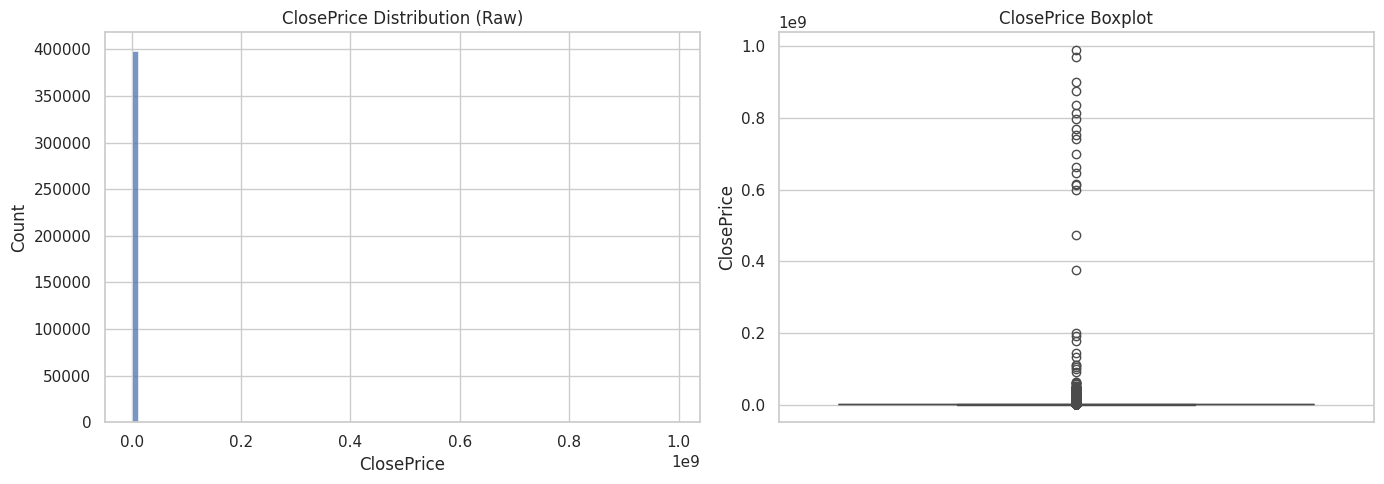

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# raw distribution
sns.histplot(df["ClosePrice"].dropna(), bins=80, ax=axes[0])
axes[0].set_title("ClosePrice Distribution (Raw)")

# boxplot
sns.boxplot(y=df["ClosePrice"].dropna(), ax=axes[1])
axes[1].set_title("ClosePrice Boxplot")

plt.tight_layout()
plt.show()

After removing the top 1% of extreme values, the ClosePrice distribution remains right-skewed, indicating the presence of a long tail of high-end properties in the California housing market.

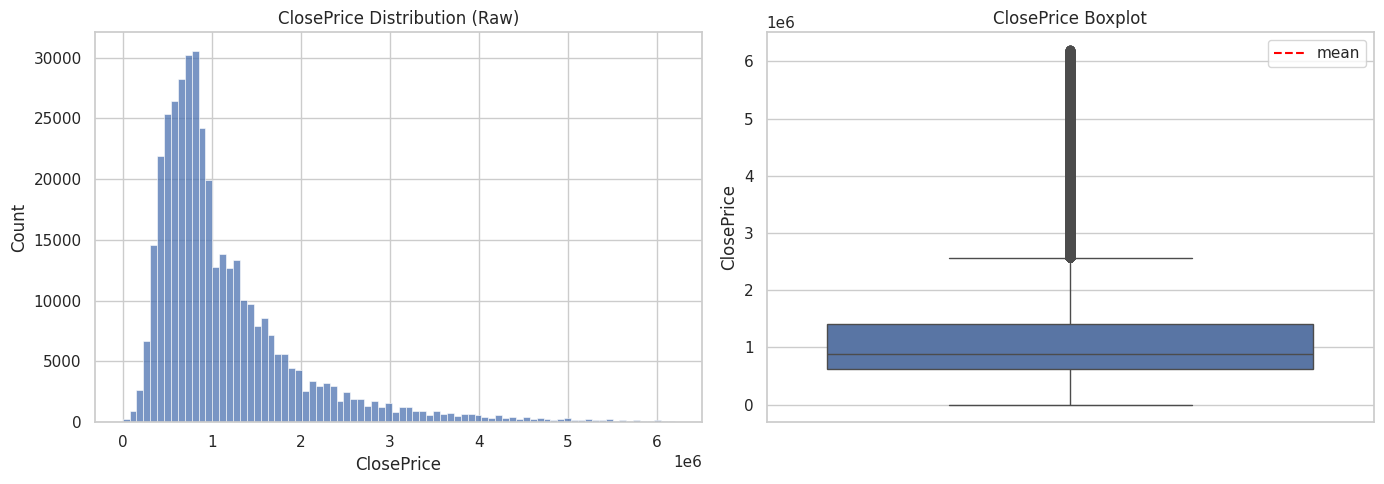

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# raw distribution
df = df[df["ClosePrice"] < df["ClosePrice"].quantile(0.99)]
sns.histplot(df["ClosePrice"].dropna(), bins=80, ax=axes[0])
axes[0].set_title("ClosePrice Distribution (Raw)")

# boxplot
sns.boxplot(y=df["ClosePrice"].dropna(), ax=axes[1])
axes[1].set_title("ClosePrice Boxplot")

plt.tight_layout()
plt.show()

### 3.2 - LivingArea

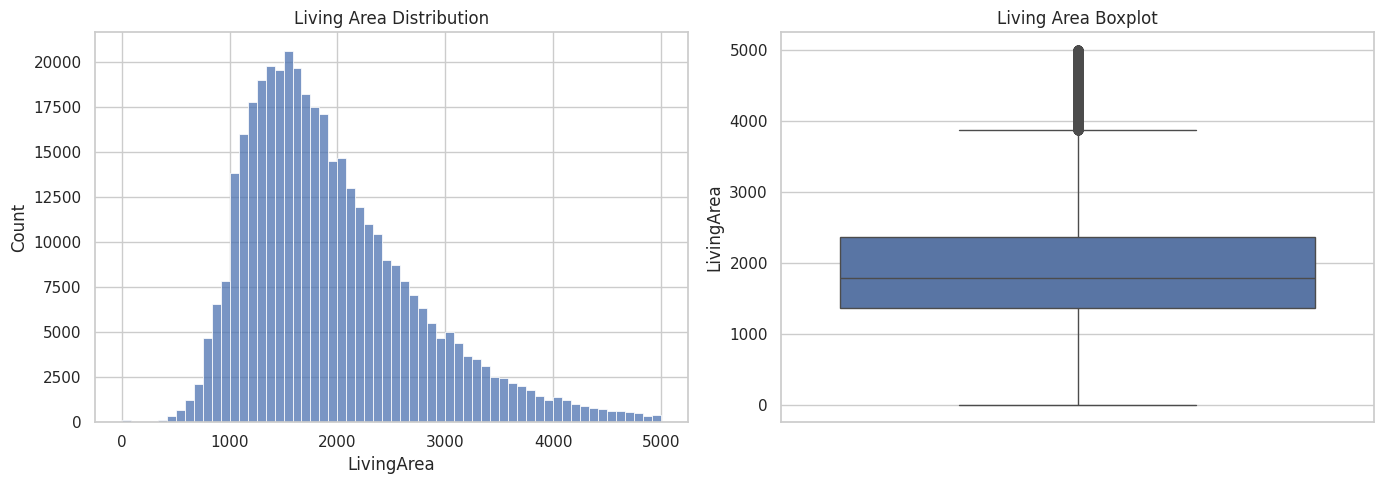

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
df = df[df["LivingArea"] < df["LivingArea"].quantile(0.999)]
sns.histplot(df["LivingArea"].dropna(), bins=60, ax=axes[0])
axes[0].set_title("Living Area Distribution")

sns.boxplot(y=df["LivingArea"].dropna(), ax=axes[1])
axes[1].set_title("Living Area Boxplot")

plt.tight_layout()
plt.show()

### 3.3 - Bedrooms

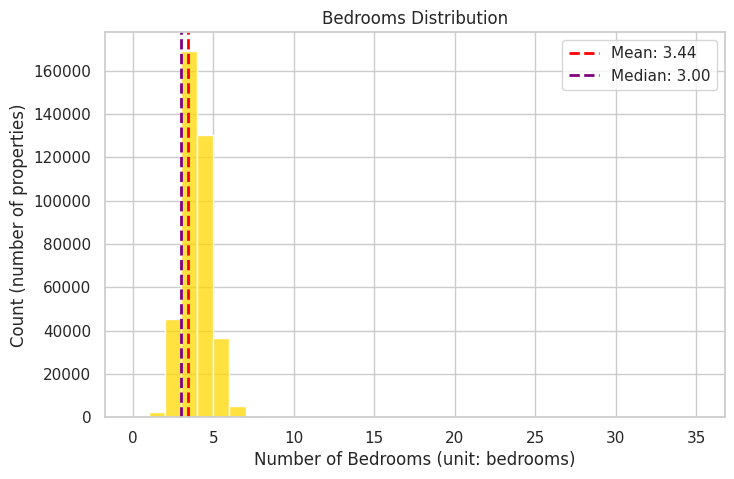

In [46]:
x = df["BedroomsTotal"].dropna()

mean_val = x.mean()
median_val = x.median()

# plot
plt.figure(figsize=(8,5))

sns.histplot(x, bins=range(int(x.min()), int(x.max()) + 2),
             kde=False, color="gold")
# mean line
plt.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.2f}")
# median line
plt.axvline(median_val, color="purple", linestyle="--", linewidth=2, label=f"Median: {median_val:.2f}")

# labels
plt.title("Bedrooms Distribution")
plt.xlabel("Number of Bedrooms (unit: bedrooms)")
plt.ylabel("Count (number of properties)")

plt.legend()
plt.show()

### 3.4 - Bathrooms

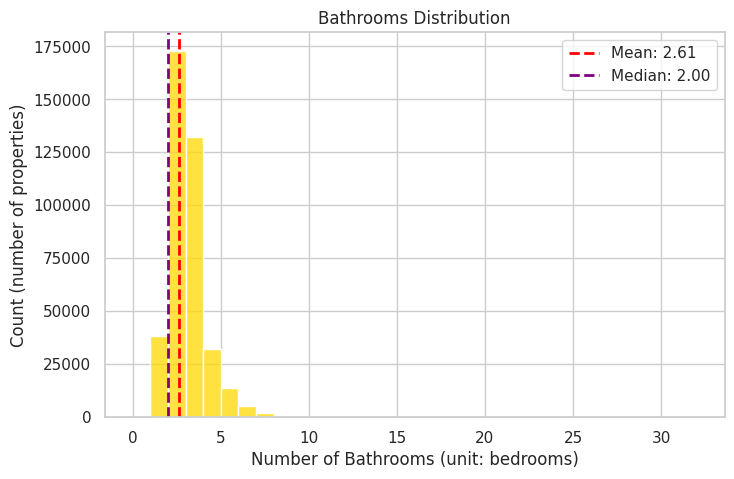

In [14]:
x = df["BathroomsTotalInteger"].dropna()

# clip at 99999%
x = x[x < x.quantile(0.99999)]

mean_val = x.mean()
median_val = x.median()

# plot
plt.figure(figsize=(8,5))

sns.histplot(x, bins=range(int(x.min()), int(x.max()) + 2),
             kde=False, color="gold")
# mean line
plt.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.2f}")
# median line
plt.axvline(median_val, color="purple", linestyle="--", linewidth=2, label=f"Median: {median_val:.2f}")

# labels
plt.title("Bathrooms Distribution")
plt.xlabel("Number of Bathrooms (unit: bedrooms)")
plt.ylabel("Count (number of properties)")

plt.legend()
plt.show()

3.5 - LotSize

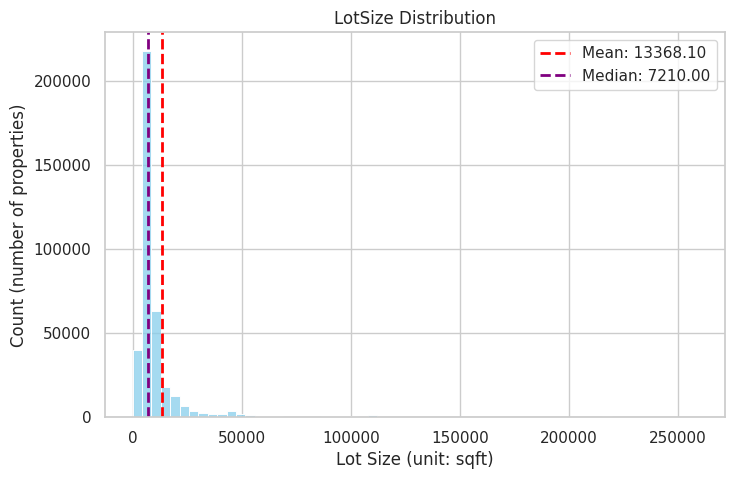

In [15]:
x = df["LotSizeSquareFeet"].dropna()

# clip extreme outliers
x = x[x < x.quantile(0.99)]

mean_val = x.mean()
median_val = x.median()

# plot
plt.figure(figsize=(8,5))

sns.histplot(x, bins=60, kde=False, color="skyblue")

# mean line
plt.axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:.2f}")

# median line
plt.axvline(median_val, color="purple", linestyle="--", linewidth=2, label=f"Median: {median_val:.2f}")

# labels
plt.title("LotSize Distribution")
plt.xlabel("Lot Size (unit: sqft)")
plt.ylabel("Count (number of properties)")

plt.legend()
plt.show()